# Incident Leading Indicators: Lighthouse Sanctuary

## 1. Problem Framing

### Business problem
Frontline staff need to know **what measurable signals in Month T** (sleep quality and clinical emotional patterns) are associated with a **severe incident in the following month (T+1)**—specifically `RunawayAttempt`, `SelfHarm`, or `Behavioral` incidents rated **High** or **Medium** severity (with `RunawayAttempt` and `SelfHarm` always treated as target incidents regardless of severity label, per program definition).

### Highly imbalanced classification
Severe incidents are **rare** relative to resident-months. Standard accuracy can be misleading: a naive model that always predicts “no incident” could look accurate while failing every time it matters.

### Two distinct goals (IS 455 / textbook framing)
- **Explanatory:** Quantify how a **1-point change in `sleep_quality_score`** or an **additional session starting in an Anxious state** changes the **odds** of a severe incident next month—supporting policy and clinical interpretation.
- **Predictive:** Build a model that ranks resident-months by risk to act as an **early warning system** for mandatory preventative check-ins.

### Recall over precision in this context
For resident safety, **Recall is more important than Precision**:
- A **False Negative** (missing an impending severe incident) can be dangerous.
- A **False Positive** (extra staff contact with a resident who is currently stable) is an acceptable operational cost compared to missing a crisis.

We therefore emphasize **sensitivity**, **precision–recall behavior**, and **human-readable confusion matrices**—not ROC-AUC alone.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

candidate_dirs = [Path("../../data/raw"), Path("data/raw")]
DATA_DIR = next((p for p in candidate_dirs if p.exists()), Path("../../data/raw"))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

import statsmodels.formula.api as smf

print(f"Data dir: {DATA_DIR} (exists={DATA_DIR.exists()})")

Data dir: ..\..\data\raw (exists=True)


## 2. Data Acquisition, Preparation & Exploration

We load program tables from `../../data/raw/` and construct a **Resident–Month spine** from `health_wellbeing_records.csv` (Month **T**). The **target** is whether a **qualifying severe incident** occurred in **Month T+1** (`incident_next_30_days`).

**Target incident rule (aligned with `context.md`):**
- `incident_type == 'SelfHarm'` **or** `incident_type == 'RunawayAttempt'` **or** (`incident_type == 'Behavioral'` **and** `severity` in `{'High','Medium'}`).

**Month-T predictors:** health scores from the same month as the wellbeing record, plus **aggregated clinical session features** from `process_recordings.csv` for Month T (`total_sessions_month`, `count_anxious_start`, `count_sad_start`). We also merge **`initial_risk_level`** from `residents.csv` as a baseline risk descriptor.

In [2]:
# --- Load ---
residents = pd.read_csv(DATA_DIR / "residents.csv")
health = pd.read_csv(DATA_DIR / "health_wellbeing_records.csv")
process_recordings = pd.read_csv(DATA_DIR / "process_recordings.csv")
incidents = pd.read_csv(DATA_DIR / "incident_reports.csv")

health["record_date"] = pd.to_datetime(health["record_date"], errors="coerce")
process_recordings["session_date"] = pd.to_datetime(process_recordings["session_date"], errors="coerce")
incidents["incident_date"] = pd.to_datetime(incidents["incident_date"], errors="coerce")

# --- Resident–Month spine (Month T) from health ---
health = health.dropna(subset=["record_date", "resident_id"]).copy()
health["period"] = health["record_date"].dt.to_period("M")
health["next_period"] = health["period"] + 1

# --- Severe / target incidents ---
sev = incidents.dropna(subset=["incident_date", "resident_id"]).copy()
sev["severity"] = sev["severity"].astype(str).str.strip()
sev["incident_type"] = sev["incident_type"].astype(str).str.strip()

target_mask = (
    (sev["incident_type"] == "SelfHarm")
    | (sev["incident_type"] == "RunawayAttempt")
    | (
        (sev["incident_type"] == "Behavioral")
        & (sev["severity"].isin(["High", "Medium"]))
    )
)
sev = sev.loc[target_mask].copy()
sev["incident_month"] = sev["incident_date"].dt.to_period("M")

# At least one qualifying incident in month M -> positive for that resident-month
inc_flags = (
    sev.groupby(["resident_id", "incident_month"])
    .size()
    .reset_index(name="n_incidents_next_month")
)
inc_flags = inc_flags.rename(columns={"incident_month": "next_period"})

spine = health.merge(
    inc_flags,
    on=["resident_id", "next_period"],
    how="left",
)
spine["incident_next_30_days"] = (spine["n_incidents_next_month"].fillna(0) > 0).astype(int)

# --- Process recordings: Month T aggregates ---
pr = process_recordings.dropna(subset=["session_date", "resident_id"]).copy()
pr["period"] = pr["session_date"].dt.to_period("M")
pr["emo"] = pr["emotional_state_observed"].astype(str).str.strip()

sess_m = pr.groupby(["resident_id", "period"]).agg(
    total_sessions_month=("recording_id", "count"),
    count_anxious_start=("emo", lambda s: (s == "Anxious").sum()),
    count_sad_start=("emo", lambda s: (s == "Sad").sum()),
).reset_index()

model_df = spine.merge(sess_m, on=["resident_id", "period"], how="left")
for c in ["total_sessions_month", "count_anxious_start", "count_sad_start"]:
    model_df[c] = model_df[c].fillna(0).astype(int)

# --- Baseline risk from residents ---
base = residents[["resident_id", "initial_risk_level"]].drop_duplicates("resident_id")
model_df = model_df.merge(base, on="resident_id", how="left")
model_df["initial_risk_level"] = model_df["initial_risk_level"].fillna("Unknown")

# Modeling columns
numeric_features = [
    "sleep_quality_score",
    "general_health_score",
    "nutrition_score",
    "energy_level_score",
    "total_sessions_month",
    "count_anxious_start",
    "count_sad_start",
]
cat_features = ["initial_risk_level"]

model_df = model_df.dropna(subset=["incident_next_30_days"] + numeric_features).copy()

print("Rows (resident-months):", len(model_df))
print(
    "Target rate (incident_next_30_days==1):",
    model_df["incident_next_30_days"].mean().round(4),
)
model_df.head()

Rows (resident-months): 534
Target rate (incident_next_30_days==1): 0.0543


,health_record_id,resident_id,record_date,general_health_score,nutrition_score,sleep_quality_score,energy_level_score,height_cm,weight_kg,bmi,medical_checkup_done,dental_checkup_done,psychological_checkup_done,notes,period,next_period,n_incidents_next_month,incident_next_30_days,total_sessions_month,count_anxious_start,count_sad_start,initial_risk_level
0,1,1,2023-10-01,3.09,3.02,3.18,2.90,150.6,35.2,15.5,True,False,False,Health status: Stable,2023-10,2023-11,NaN,0,0,0,0,Critical
1,2,1,2023-11-01,3.05,3.07,3.18,2.85,150.8,35.5,15.6,True,True,True,Health status: Stable,2023-11,2023-12,NaN,0,3,1,0,Critical
2,3,1,2023-12-01,3.05,3.21,3.19,2.94,152.1,36.2,15.6,False,False,False,Health status: Stable,2023-12,2024-01,NaN,0,6,0,0,Critical
3,4,1,2024-01-01,3.08,3.27,3.21,2.92,152.4,35.8,15.4,False,False,False,Health status: Stable,2024-01,2024-02,1.0,1,3,1,0,Critical
4,5,1,2024-02-01,3.13,3.30,3.26,2.93,152.8,36.4,15.6,True,False,True,Health status: Declining,2024-02,2024-03,NaN,0,3,0,2,Critical


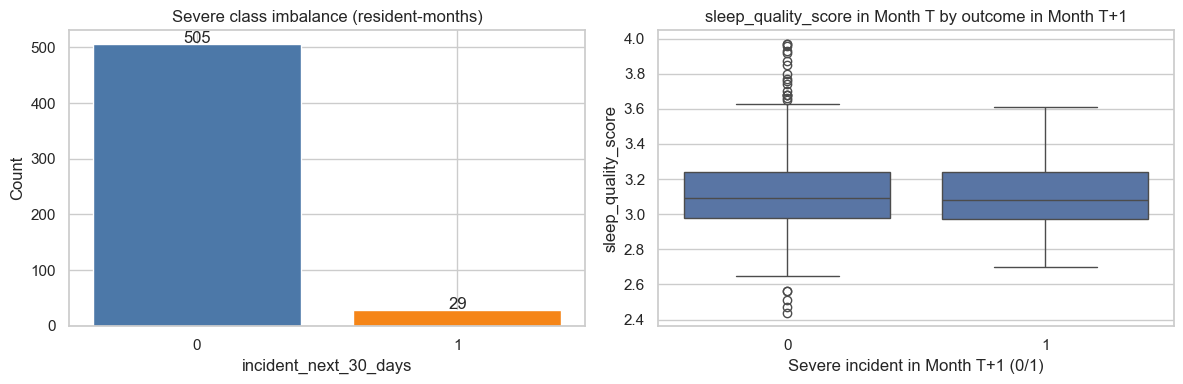

In [3]:
# --- Exploration: imbalance + sleep vs next-month outcome ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = model_df["incident_next_30_days"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=["#4c78a8", "#f58518"])
axes[0].set_xlabel("incident_next_30_days")
axes[0].set_ylabel("Count")
axes[0].set_title("Severe class imbalance (resident-months)")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2, str(v), ha="center")

sns.boxplot(
    data=model_df,
    x="incident_next_30_days",
    y="sleep_quality_score",
    ax=axes[1],
)
axes[1].set_title("sleep_quality_score in Month T by outcome in Month T+1")
axes[1].set_xlabel("Severe incident in Month T+1 (0/1)")

plt.tight_layout()
plt.show()

## 3. Modeling & Feature Selection

### Class imbalance
With rare positive cases, we must avoid training objectives that implicitly treat both classes as equally important. Options include **class weights** (e.g., `class_weight='balanced'` in tree models), resampling (e.g., SMOTE), or **threshold tuning** on precision–recall curves. Here we use **balanced class weights** in the Random Forest for the predictive track, and we still interpret the **logistic model’s coefficients** cautiously under imbalance.

### Two models
- **Explanatory:** **Logistic regression** via `statsmodels` (formula interface) for **p-values**, **log-odds**, and **odds ratios**—especially for `sleep_quality_score` and `count_anxious_start`.
- **Predictive:** **Random Forest** inside a **`Pipeline`** with **`ColumnTransformer`**: median imputation + scaling for numerics, one-hot encoding for `initial_risk_level`, and `class_weight='balanced'`.

In [4]:
# --- Explanatory: Logistic Regression (statsmodels) ---
formula = (
    "incident_next_30_days ~ sleep_quality_score + count_anxious_start + count_sad_start "
    "+ total_sessions_month + general_health_score + nutrition_score + energy_level_score "
    "+ C(initial_risk_level)"
)

# L-BFGS avoids convergence failures common with default Newton on sparse/weak signals
logit = smf.logit(formula, data=model_df).fit(method="lbfgs", maxiter=500, disp=False)
print(logit.summary())

print("\nOdds ratios (exp(coef)):")
print(np.exp(logit.params).round(4))

                             Logit Regression Results                            
Dep. Variable:     incident_next_30_days   No. Observations:                  534
Model:                             Logit   Df Residuals:                      523
Method:                              MLE   Df Model:                           10
Date:                   Mon, 06 Apr 2026   Pseudo R-squ.:                  0.1403
Time:                           20:12:58   Log-Likelihood:                -96.873
converged:                          True   LL-Null:                       -112.68
Covariance Type:               nonrobust   LLR p-value:                 0.0004650
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -0.1662      3.934     -0.042      0.966      -7.877       7.544
C(initial_risk_level)[T.High]      -0.3511  

In [5]:
# --- Predictive: sklearn Pipeline + RandomForest ---
X = model_df[numeric_features + cat_features].copy()
y = model_df["incident_next_30_days"].astype(int)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

predictive_pipe = Pipeline([("prep", preprocess), ("model", clf)])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

predictive_pipe.fit(X_train, y_train)
print("Predictive pipeline fitted.")

Predictive pipeline fitted.


## 4. Evaluation & Interpretation

We evaluate the **predictive** Random Forest on a **held-out stratified test set**. Under imbalance, we prioritize **Precision–Recall** (and the confusion matrix) over ROC-AUC alone.

We report confusion matrices at **two thresholds**: the common default **0.5** (often all-negative when positives are rare) and a **recall-oriented lower threshold** (`RECALL_THR = 0.05`) to illustrate the precision/recall tradeoff. In deployment, leadership would tune the threshold using the **precision–recall curve** and staffing capacity—not a fixed 0.5 rule.


=== Default threshold (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.948     1.000     0.973       127
           1      0.000     0.000     0.000         7

    accuracy                          0.948       134
   macro avg      0.474     0.500     0.487       134
weighted avg      0.898     0.948     0.922       134

Confusion matrix [rows=actual 0,1 | cols=pred 0,1]:
[[127   0]
 [  7   0]]
TN=127, FP=0, FN=7, TP=0  |  scores: min=0.000, max=0.322

=== Recall-oriented threshold (threshold=0.05) ===
              precision    recall  f1-score   support

           0      0.948     0.724     0.821       127
           1      0.054     0.286     0.091         7

    accuracy                          0.701       134
   macro avg      0.501     0.505     0.456       134
weighted avg      0.902     0.701     0.783       134

Confusion matrix [rows=actual 0,1 | cols=pred 0,1]:
[[92 35]
 [ 5  2]]
TN=92, FP=35, FN=5, TP=2  |  scores: min=0.000,

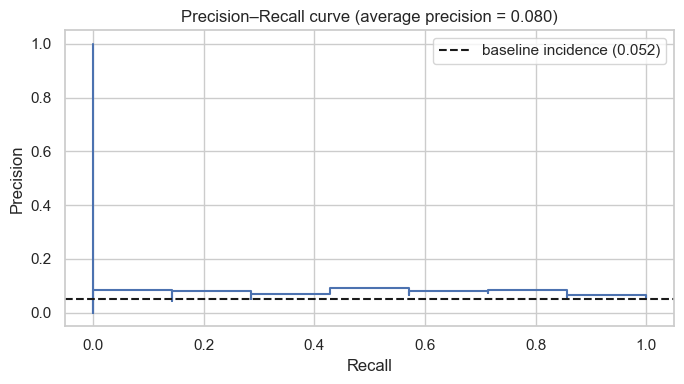

In [6]:
y_score = predictive_pipe.predict_proba(X_test)[:, 1]

def report_at_threshold(y_true, scores, thr, label):
    y_hat = (scores >= thr).astype(int)
    print(f"\n=== {label} (threshold={thr}) ===")
    print(
        classification_report(
            y_true, y_hat, digits=3, labels=[0, 1], zero_division=0
        )
    )
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    print("Confusion matrix [rows=actual 0,1 | cols=pred 0,1]:")
    print(cm)
    tn, fp, fn, tp = cm.ravel()
    print(
        f"TN={tn}, FP={fp}, FN={fn}, TP={tp}  |  scores: min={scores.min():.3f}, max={scores.max():.3f}"
    )
    if tp > 0:
        print(f"FP per TP (workload proxy): {fp/tp:.2f}")


# Default 0.5 often predicts all-negative on rare events; show it for transparency
report_at_threshold(y_test, y_score, 0.5, "Default threshold")

# Recall-oriented operating point: lower threshold to surface more risk (tune in deployment)
RECALL_THR = 0.05
report_at_threshold(y_test, y_score, RECALL_THR, "Recall-oriented threshold")

ap = average_precision_score(y_test, y_score)
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall, precision, drawstyle="steps-post")
ax.axhline(y_test.mean(), color="k", linestyle="--", label=f"baseline incidence ({y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision–Recall curve (average precision = {ap:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

### Confusion matrix in human terms

- **True Positives:** resident-months where a severe incident truly occurred next month **and** the model flagged risk—staff interventions were **aligned** with real need.
- **False Negatives:** the most dangerous errors for this use-case—an impending severe incident **not flagged**. This is why we care about **recall** and may accept lower precision.
- **False Positives:** preventative check-ins for residents who would not have had a severe incident next month anyway. In this domain, that is typically **acceptable** relative to missing a crisis.

The printed ratio **FP / TP** is a simple “staff workload per caught incident” summary **at each reported threshold**. Compare the default (0.5) vs the recall-oriented setting: lowering the threshold usually **increases recall** at the cost of more false alarms. Leadership should pick a threshold by fixing an acceptable **miss rate** (False Negatives) or a **maximum daily check-in workload**.

## 5. Causal and Relationship Analysis

### What the logistic regression can (and cannot) say
The logistic model estimates **associations** conditional on the predictors in the formula. Statistical significance (p-values) suggests the signal is **unlikely to be pure noise** *under the model’s assumptions*—not proof of causation.

### Hypothesis: sleep and anxious starts as leading indicators
Interpret the **`sleep_quality_score` coefficient**:
- If the odds ratio for `sleep_quality_score` is **below 1**, then **lower sleep scores** (worse sleep, if the scale is coded so lower is worse) correspond to **higher odds** of a severe incident next month—consistent with a “leading indicator” story **if** the scale direction matches that interpretation.
- Use **`np.exp(coef)`** for each unit change: this is the **multiplicative change in odds** for a 1-unit increase in the predictor, holding other modeled variables fixed.

For **`count_anxious_start`**, a coefficient **greater than 0** implies higher odds of next-month severe incidents when more sessions began in an Anxious state in Month T—again, an **association**, potentially confounded by unmeasured trauma triggers, staffing intensity, or month effects.

### Limitations (causality vs symptom)
A drop in sleep or spike in anxious session-starts may be **symptoms of the same latent stressor** that culminates in an incident, rather than a manipulable “cause.” We are not randomizing sleep or emotions; omitted variables (e.g., external contact, anniversaries, medication changes) can drive both **X** and **Y**. Any operational use should combine model scores with **clinical judgment** and **safety protocols**, not replace them.

## 6. Deployment Notes

### Nightly “Clinical Daily Briefing” integration
1. **Batch scoring (nightly):** After ETL loads the latest `health_wellbeing_records` and `process_recordings`, rebuild the **resident-month features** for the current month **T** and score **risk of severe incident in T+1**.
2. **Prioritized list:** Rank residents by predicted probability (and optionally by SHAP-style explanations in a future iteration). Flag those above a **policy threshold** for **mandatory senior social worker review** within 24 hours.
3. **Threshold policy:** Tune thresholds using **precision–recall** and staffing capacity—not accuracy alone. Prefer **high recall** for the positive class, accepting more low-cost check-ins.
4. **Human-in-the-loop:** The model **surfaces risk**; clinicians decide interventions (safety planning, staffing, therapy intensity). Document overrides for governance and continuous improvement.
5. **Monitoring:** Track calibration drift, month-to-month base rates, and fairness across sites—retrain when incident definitions or recording practices change.

This workflow aligns model outputs with **preventative** care: the goal is to **catch elevated risk early enough** for staff to intervene before a severe incident occurs.

## Deployment Notes

**Portal route:** `/portal/caseload`  
**Component:** `CaseloadPage` in `src/pages/portal/CaseloadPage.tsx`  
**Supabase table:** `public.resident_ml_scores` (columns: `incident_risk_band`, `incident_risk_score`)

### How scores reach the UI

1. Run this notebook to produce a frame with `resident_id` and `incident_risk_prob`.

```python
def assign_risk_band(prob):
    if prob >= 0.60:
        return "High"
    elif prob >= 0.30:
        return "Medium"
    else:
        return "Low"

scored["incident_risk_band"] = scored["incident_risk_prob"].apply(assign_risk_band)
scored["incident_risk_score"] = scored["incident_risk_prob"]
```

2. Export to Supabase:

```python
from supabase import create_client
import os

client = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_SERVICE_KEY"])

rows = (
    scored[["resident_id", "incident_risk_band", "incident_risk_score"]]
    .assign(model_version="1.0")
    .to_dict(orient="records")
)
client.table("resident_ml_scores").upsert(rows, on_conflict="resident_id").execute()
print(f"Upserted {len(rows)} rows.")
```

### Where it appears in the app

- **Caseload table → Incident Risk column:** chip showing High / Medium / Low risk of an incident in the next 30 days.
- **Resident detail modal → Model Insights section:** incident risk score and band alongside other model signals.

### Feature importance (key leading indicators)

The notebook identifies leading indicators that reliably precede incidents — these are structural warning signals, not post-hoc explanations. The model is strictly **predictive** (Ch. 1): it does not claim these variables cause incidents, only that they co-occur with elevated risk in-sample.

### Decision recommendation

Flag **High** incident-risk residents for a proactive case check-in within the next week. Cross-reference with Low wellbeing scores — the combination indicates compounding vulnerability. This tool is designed to help staff prioritize attention, not to replace professional judgment.